## MIPEM: Media Ingredient Prediction for Environmental Microorganisms

In [1]:
import pandas as pd
import os
import numpy as np

### User input: <br>
<u> **Insert your data here, and run the notebook.** </u> <br>
* A PDF report will be generated in your current working directory (**DATA_DIR**). <br>
* **TEST_FILE** should be your organism's .csv file, with two columns: ["filename", "ec"]. These can be extracted from a .gff file in the 01-Data.ipynb notebook ("MAG Processing" section), or prepared independently.

In [2]:
DATA_DIR = "~/Desktop/Projects/media-prediction/" # Replace with the path to this repository 
TEST_FILE = pd.read_csv(os.path.join(DATA_DIR, "data", "test.csv")) # Replace "test.csv" with your file

# [OPTIONAL] If your file contains multiple organisms ("filename" column), you can adjust this filter to extract your organism of interest #
OOI = "Bin.003.fastaCG_F" 

### Initialization

Note: some notebooks were generated outside of this workflow by merging outputs from 01-Data.ipynb (e.g., UMAP_input.csv, test.csv, and ec-cofactor.csv)

In [3]:
# Setting random environment
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
RANDOM_SEED = 26

# For collecting report figures
from matplotlib.backends.backend_pdf import PdfPages
facet_figs = []

### Format input

In [4]:
# Upload test case (.csv with columns ["filename", "ec"])
test_df = TEST_FILE.copy()

# Select a single test sample if file contains multiple
bin = test_df[test_df["filename"].str.contains(OOI, na=False)]

# Format for UMAP
bin = bin[["filename", "ec"]].value_counts().reset_index()
test = bin.pivot(index=["filename"], columns="ec", values="count").fillna(0.0)

test.head()

ec,1.11.1.15,1.15.1.1,1.2.7.3,1.3.1.98,2.1.1.170,2.1.1.177,2.1.1.192,2.1.1.193,2.1.1.198,2.1.1.199,...,6.1.1.2,6.1.1.20,6.1.1.3,6.1.1.4,6.1.1.6,6.1.1.7,6.1.1.9,6.3.5.6,7.1.2.2,7.4.2.8
filename,,,,,,,,,,,,,,,,,,,,,
KBase_derived_Bin.003.fastaCG_F_extracted_bins.AssemblySet_DRAM.gff,1,1,1,1,1,1,1,1,1,1,...,1,2,1,1,1,1,1,2,2,1


In [5]:
# Load constructed dataset
df = pd.read_csv(os.path.join(DATA_DIR, "data", "UMAP_input.csv"), low_memory=False)

df.head()

,taxon_id,media_id,1.1.1.1,1.1.1.100,1.1.1.101,1.1.1.102,1.1.1.103,1.1.1.105,1.1.1.107,1.1.1.108,...,7.6.2.12,7.6.2.13,7.6.2.14,7.6.2.15,7.6.2.16,7.6.2.2,7.6.2.5,7.6.2.7,7.6.2.8,7.6.2.9
0,100.0,J346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100.0,J386,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100225.0,J233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1002526.0,J22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1004166.0,1a,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### UMAP (unsupervised)
UMAP is used to reduce dimensionality and map the test organism to the metabolic space of the training dataset. Use this in combination with the K-Nearest Neighbors to visualize how closely your organism fits with the training dataset to inform media predictions.

#### UMAP model

In [6]:
# UMAP dimensionality reduction
import umap

model = umap.UMAP(      
        metric="jaccard",
        n_epochs=500,
        random_state=RANDOM_SEED,
        n_jobs=1,
        n_components=20, 
        n_neighbors=40, 
        min_dist=0.1 
        )

# Fit/transform data using UMAP
X_train = df.drop(["taxon_id", "media_id"], axis=1)
X_train_transformed = model.fit_transform(X_train)

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


SystemError: CPUDispatcher(<function nn_descent at 0x000001E82E430400>) returned a result with an exception set

In [ ]:
# Check disconnected vertices
nan_rows = np.isnan(X_train_transformed).any(axis=1)
n_samples = X_train_transformed.shape[0]
n_nan_rows = np.isnan(X_train_transformed).any(axis=1).sum()
percent_nan_rows = 100 * n_nan_rows / n_samples

print(percent_nan_rows, "percent of embedded samples are nan (disconnected vertices / total samples).")

0.7088846880907372 percent of embedded samples are nan (disconnected vertices / total samples).


#### Clustering

In [ ]:
# Cluster embedding
from sklearn.cluster import KMeans

X_train_clean = X_train_transformed[~nan_rows]
clusterer = KMeans(n_clusters=14, n_init=50, random_state=RANDOM_SEED)
cluster_labels = clusterer.fit_predict(X_train_clean)

# Clustering performance
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_train_clean, cluster_labels)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


14 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.7286314964294434


#### Transform test case

In [ ]:
# Resize test case to include all of the same EC numbers as the training dataset
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

train = df.copy()
train = train.drop(["taxon_id", "media_id"], axis=1)

for col in train.columns:
    if col not in test.columns:
        test[col] = 0

test = test[train.columns]

# Transform the test case with UMAP
test_embedding = model.transform(test)

#### Feature Importance

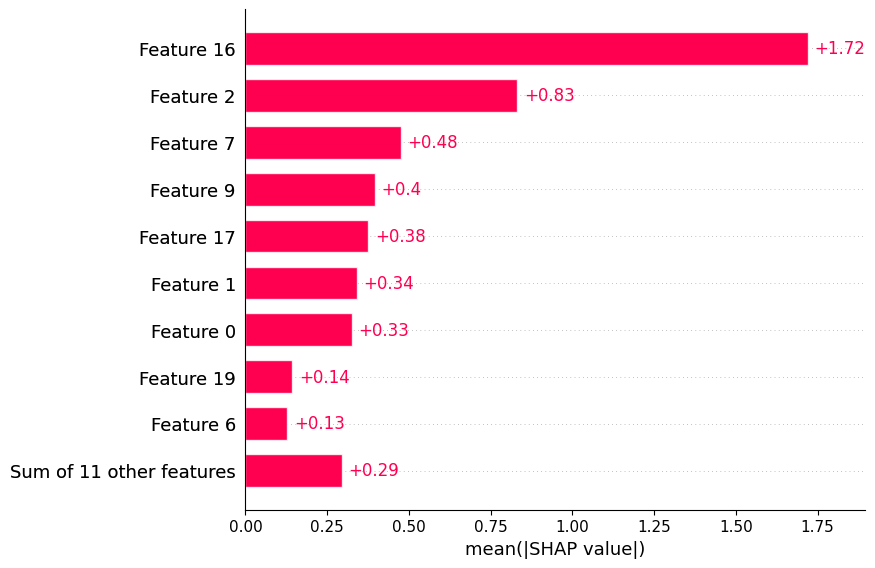

In [ ]:
# UMAP Features
import xgboost
import shap

XG_train = X_train_clean
yG_train = cluster_labels

model = xgboost.XGBRegressor().fit(XG_train, yG_train)
explainer = shap.Explainer(model)
shap_values = explainer(XG_train)

shap.plots.initjs()
shap.plots.bar(shap_values)

#### Visualization

In [ ]:
fig = plt.figure(figsize=(8, 6))

fig.text(0.1, 0.80, "UMAP metrics:", fontsize=14, fontweight="bold")
fig.text(
    0.1, 0.75,
    f"{percent_nan_rows:.2f}% of training set samples were disconnected using the Jaccard metric.", 
    fontsize=12
)
fig.text(
    0.1, 0.70,
    f"{clusterer.labels_.max()+1} kmeans training clusters were utilized.",
    fontsize=12
)
fig.text(
    0.1, 0.65,
    f"Silhouette score for kmeans clusters: {silhouette_avg:.2f}.",
    fontsize=12
)

facet_figs.append(plt.gcf()) 

<Figure size 800x600 with 0 Axes>

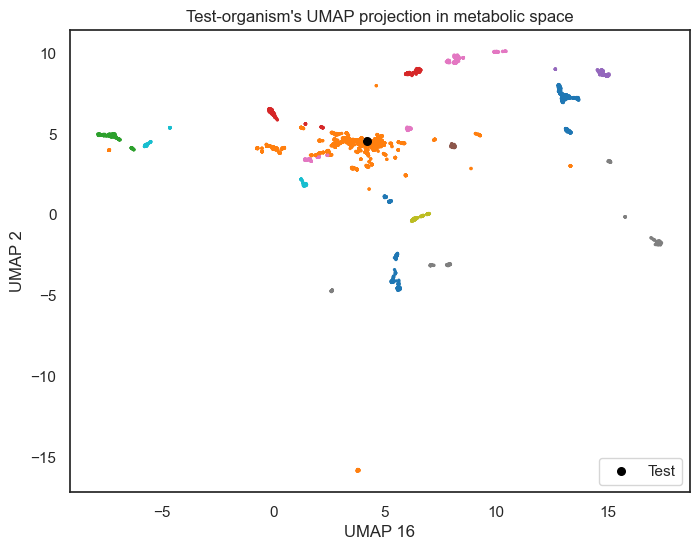

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Reference organisms from constructed dataset
plt.scatter(X_train_clean[:, 15], X_train_clean[:, 1], c=cluster_labels, cmap="tab10", s=2)
# Components 16 and 2 determined highest importance via XGBoost/Shap

# Test sample
plt.scatter(test_embedding[0, 0], test_embedding[0, 1], c="black", s=30, label="Test")

plt.xlabel("UMAP 16")
plt.ylabel("UMAP 2")
plt.title("Test-organism's UMAP projection in metabolic space")
plt.legend(loc="lower right")

#plt.show() # hide if saving to .pdf
facet_figs.append(plt.gcf()) 

### Prediction

#### Nearest neighbors (unsupervised)

In [ ]:
# Function for finding nearest neighbors via the jaccard metric (uses original dataset)
from sklearn.neighbors import NearestNeighbors

def get_nearest_neighbors(X_train, new_sample, k=10, metric="jaccard", algorithm="auto"):
    nn = NearestNeighbors(n_neighbors=k, metric="jaccard")
    nn.fit(train)
    distances, indices = nn.kneighbors(test)
    
    return distances[0], indices[0]

In [ ]:
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor

# Return nearest neighbors (existing output, assign Jaccard distances)
distances, indices = get_nearest_neighbors(train, test, k=10)

neighbors = df.iloc[indices][['taxon_id', 'media_id']].copy()
neighbors['jaccard_distance'] = distances

nearest_info = df.iloc[indices][['taxon_id', 'media_id']].copy()

print("Nearest neighbors:")
display(neighbors)

# kNN distance percentile (global distribution)
k = 10
nn_all = NearestNeighbors(n_neighbors=k+1, metric='jaccard')
nn_all.fit(train)

train_dists, _ = nn_all.kneighbors(train)
train_mean_dists = train_dists[:, 1:].mean(axis=1)

test_mean_dist = distances.mean()
knn_percentile = (train_mean_dists < test_mean_dist).mean() * 100

print(f"\n Confidence metrics:")
print(f"kNN distance percentile: {knn_percentile:.1f}%")

# Local Outlier Factor (LOF; local distribution)
lof = LocalOutlierFactor(n_neighbors=10, metric='jaccard', novelty=True)
lof.fit(train)

lof_score = -lof.score_samples(test)[0]
train_lof = -lof.score_samples(train)
lof_percentile = (train_lof < lof_score).mean() * 100

print(f"LOF percentile: {lof_percentile:.1f}%")

Nearest neighbors:


c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


,taxon_id,media_id,jaccard_distance
6419,47834.0,1076b,0.803419
362,1136073.0,1076b,0.814159
6420,47835.0,1076b,0.817460
5422,358687.0,J346,0.840764
5357,351343.0,J346,0.840764
6045,424799.0,J346,0.840764
646,126734.0,1012a,0.841530
1797,1597.0,J84,0.845588
7347,650366.0,J13,0.845588
1400,1490.0,J84,0.845588


c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



 Confidence metrics:
kNN distance percentile: 98.2%


c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(

LOF percentile: 75.9%


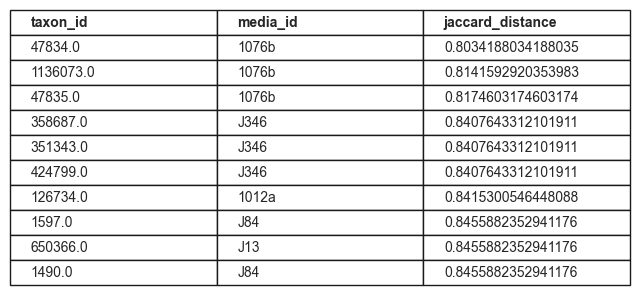

In [ ]:
# Nearest neighbors to table for report:
neighbors_table = neighbors.copy()

n_rows = len(neighbors_table)
fig_height = max(2, n_rows * 0.25)  # minimum height = 2

fig_table, ax_table = plt.subplots(figsize=(8, fig_height))
ax_table.axis('off')
table_data = [neighbors_table.columns.tolist()] + neighbors_table.values.tolist()

table_artist = ax_table.table(cellText=table_data, cellLoc='left', loc='center')
table_artist.auto_set_font_size(False)
table_artist.set_fontsize(10)
table_artist.scale(1, 1.5)

for (row, col), cell in table_artist.get_celld().items():
    if row == 0: 
        cell.set_text_props(weight='bold')

facet_figs.append(fig_table)

In [ ]:
# Interpret kNN distance percentile
if knn_percentile < 80:
    knn_label = "In-distribution (typical global distance)"
elif knn_percentile < 95:
    knn_label = "Extrapolative (globally distant)"
else:
    knn_label = "Out-of-distribution (very distant)"

# Interpret LOF percentile
if lof_percentile < 80:
    lof_label = "Normal local density"
elif lof_percentile < 95:
    lof_label = "Locally sparse"
else:
    lof_label = "Strong local outlier"

# Combined interpretation
if knn_percentile > 95 and lof_percentile > 95:
    combined_label = "Strong outlier: globally distant and locally isolated"
elif knn_percentile > 95 and lof_percentile <= 80:
    combined_label = "Distinct but coherent metabolic niche"
elif knn_percentile <= 80 and lof_percentile > 95:
    combined_label = "Boundary case between metabolic clusters"
else:
    combined_label = "Consistent with training distribution"

#print("Metric interpretation:")
#print(f"kNN distance percentile: {knn_percentile:.1f}% → {knn_label}")
#print(f"LOF percentile: {lof_percentile:.1f}% → {lof_label}")
#print(f"Overall assessment: {combined_label}")

# Save as a figure for .pdf report
fig = plt.figure(figsize=(8, 6))

fig.text(0.1, 0.85, "kNN metrics for sample of interest:", fontsize=12, weight="bold")
fig.text(0.1, 0.80, f"kNN distance percentile: {knn_percentile:.1f}%", fontsize=12)
fig.text(0.1, 0.75, f"Meaning: {knn_label}", fontsize=12)
fig.text(0.1, 0.70, f"LOF percentile: {lof_percentile:.1f}%", fontsize=12)
fig.text(0.1, 0.65, f"Meaning: {lof_label}", fontsize=12)

fig.text(0.1, 0.55, "Overall assessment:", fontsize=12, weight="bold")
fig.text(0.1, 0.50, combined_label, fontsize=12)

facet_figs.append(fig)

<Figure size 800x600 with 0 Axes>

#### Nearest neighbor media

In [ ]:
neighbors_df = pd.DataFrame(nearest_info)

# Show the media of the nearest neighboring taxa based on their metabolic characteristics
media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False) #"mediadive-complete-explo.csv"
prediction = pd.merge(left=neighbors_df, right=media_df, on="media_id", how="left")
prediction = prediction.drop(["taxon_id"], axis=1)

# Occurrence column shows how many of the neighbors utilize each media type
prediction["occurrence"] = prediction["media_id"].map(prediction["media_id"].value_counts(normalize=True))
prediction = prediction.drop_duplicates()

prediction.head()

,media_id,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml,occurrence
0,1076b,[2173],['Main sol. 1076b'],"['PPLO broth', 'Tryptone', 'Bacto peptone', 'D...","[953, 71, 19, 4, 958, 1680, 16, 954, 960, 5, 3...","[3.5, 10, 5, None, 0.2, None, 0.4, None, None,...",[[{'step': 'The difference between this medium...,[],[],[],0.3
3,J346,[4066],['Main sol. J346'],"['Yeast extract', 'Proteose peptone no. 3', 'C...","[16, 316, 101, 5, 199, 438, 10, 8, 3, 4]","[0.5, 0.5, 0.5, 0.5, 0.5, 0.3, 0.3, 0.05, 15, ...","[[{'step': 'Adjust pH to 7.2.'}, {'step': 'Com...",[],[],[],0.3
6,1012a,[6336],['Main sol. 1012a'],"['Nutrient broth', 'Casamino acids', 'Yeast ex...","[269, 101, 16, 3, 79, 7, 4]","[0.8, 0.5, 0.1, 12, 0.6, 0.3, None]",[[{'step': 'Preparation of double-layered agar...,[],[],[],0.1
7,J84,[3711],['Main sol. J84'],"['GAM broth', 'Agar', 'Distilled water']","[1620, 3, 4]","[59, 2, None]",[None],[],[],[],0.2
8,J13,"[3632, 3633, 3634]","['Main sol. J13', 'Solution A', 'Solution B']","['Lab-Lemco beef extract', 'Proteose peptone n...","[599, 316, 124, 125, 16, 1600, 5, 199, 22, 3, ...","[2.85714, 9.52381, 4.7619, 2.85714, 4.7619, No...","[[{'step': 'Adjust pH to 7.2.'}, {'step': 'To ...","['Solution A', 'Solution B']","[3633, 3634]","[10, 5]",0.1


C:\Users\jakel\AppData\Local\Temp\ipykernel_8384\3964649466.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_display['components'] = df_display['components'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


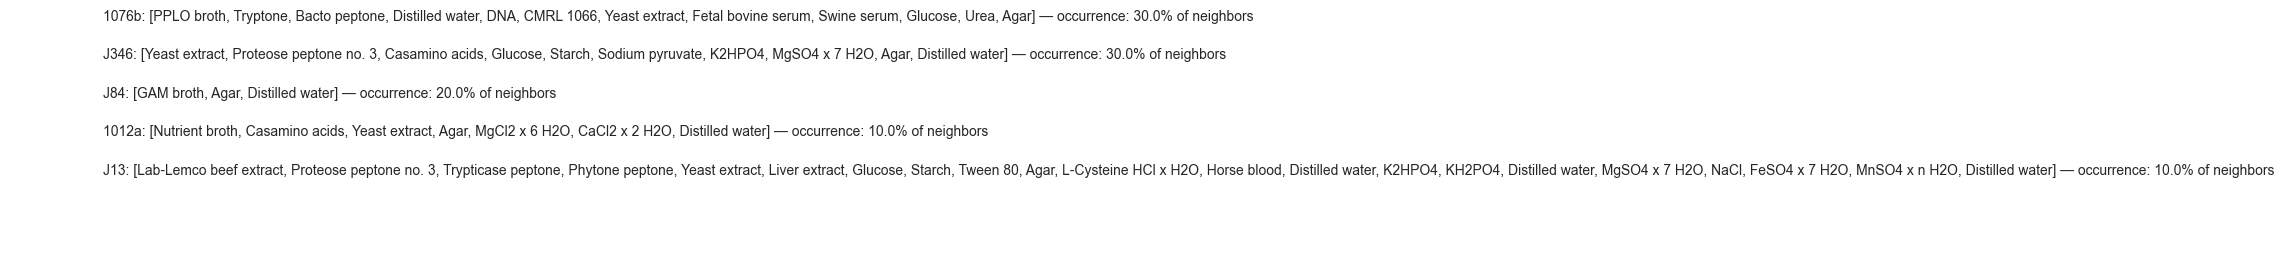

In [ ]:
import ast

# Media occurrence to table for report
df_sorted = prediction.sort_values(by="occurrence", ascending=False)
df_display = df_sorted[['media_id', 'components', 'occurrence']]
df_display['components'] = df_display['components'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Create figure
fig, ax = plt.subplots(figsize=(12, len(df_display)*0.4 + 1))
ax.axis('off')  # hide axes

# Spacing
y = 1 
y_step = 1 / (len(df_display) + 1)  

for idx, row in df_display.iterrows():
    media_id = row['media_id']
    components = row['components']
    occurrence_pct = row['occurrence'] * 100
    components_str = ", ".join(components)
    
    text_str = f"{media_id}: [{components_str}] — occurrence: {occurrence_pct:.1f}% of neighbors"
    
    ax.text(0.1, y, text_str, fontsize=10,
            
            transform=ax.transAxes) #bbox=dict(facecolor='white', alpha=0.3, boxstyle='round,pad=0.3'),
    
    y -= y_step

facet_figs.append(fig)

In [ ]:
import ast

# Interpreting prediction results
df = prediction.copy()

df["components"] = df["components"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_exploded = df.explode("components")

n_media = df["media_id"].nunique()
component_media_counts = (df_exploded.groupby("components")["media_id"].nunique())

# Components shared by at least two media
components_shared_by_at_least_two = (
    component_media_counts[component_media_counts >= 2]
        .index
        .tolist()
)

# Components shared by all media
components_shared_by_all = (
    component_media_counts[component_media_counts == n_media]
        .index
        .tolist()
)

# --- Optional: clean printing ---
print("Shared by at least two media:")
print(components_shared_by_at_least_two)

print("\nShared by all media:")
print(components_shared_by_all)


Shared by at least two media:
['Agar', 'Casamino acids', 'Distilled water', 'Glucose', 'K2HPO4', 'MgSO4 x 7 H2O', 'Proteose peptone no. 3', 'Starch', 'Yeast extract']

Shared by all media:
['Agar', 'Distilled water']


C:\Users\jakel\AppData\Local\Temp\ipykernel_8384\457279995.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_display['components'] = df_display['components'].apply(


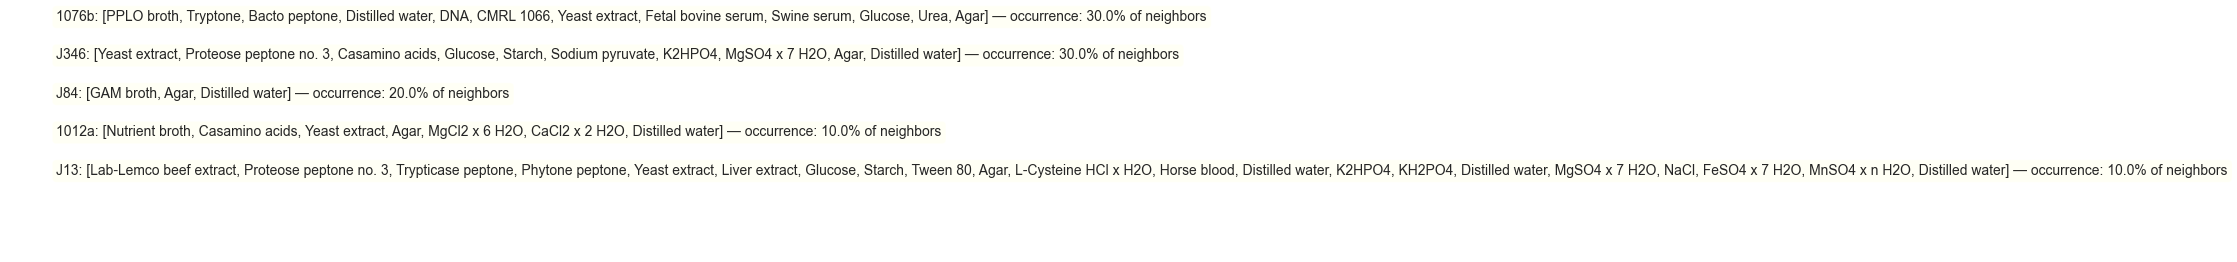

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Prepare the dataframe ---
# Keep only the columns we need
df_display = df_sorted[['media_id', 'components', 'occurrence']]

# If 'components' is stringified, convert to lists
import ast
df_display['components'] = df_display['components'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# --- 2. Create a figure ---
fig, ax = plt.subplots(figsize=(12, len(df_display)*0.4 + 1))
ax.axis('off')  # hide axes

# --- 3. Add one text box per media_id ---
y = 1  # start at top of figure
y_step = 1 / (len(df_display) + 1)  # spacing

for idx, row in df_display.iterrows():
    media_id = row['media_id']
    components = row['components']
    occurrence_pct = row['occurrence'] * 100

    # Format components nicely as a string
    components_str = ", ".join(components)
    
    # Construct text line
    text_str = f"{media_id}: [{components_str}] — occurrence: {occurrence_pct:.1f}% of neighbors"
    
    # Add text box
    ax.text(0.05, y, text_str, fontsize=10,
            bbox=dict(facecolor='lightyellow', alpha=0.3, boxstyle='round,pad=0.3'),
            transform=ax.transAxes)
    
    y -= y_step

# --- 4. Add this figure to your list of figures for the PDF ---
facet_figs.append(fig)


#### Cofactor comparison

In [ ]:
# Load training set EC and cofactor info
training_cofactors = pd.read_csv(os.path.join(DATA_DIR, "data", "ec-cofactor.csv"))

# Filter for the nearest neighbors (rather than entire training dataset)
neighbors_list = nearest_info["taxon_id"].to_list()
filt = training_cofactors["taxon_id"].isin(neighbors_list)
train_co = training_cofactors[filt]

train_co.head()

,media_id,taxon_id,source,ec,CofactorFinal
100676,1012a,126734.0,uniprot,3.6.1.66,Mg
100677,1012a,126734.0,uniprot,2.1.1.192,Fe
100678,1012a,126734.0,uniprot,2.7.4.3,Mg
100679,1012a,126734.0,uniprot,3.1.26.3,Mg
100680,1012a,126734.0,uniprot,4.2.1.113,metal


In [ ]:
# Align test case cofactor info based on EC numbers
test_co = bin[["filename", "ec"]]
tr_co = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "cofactors-taxa.csv"), low_memory=False)
tr_co = tr_co[["Query EC", "CofactorFinal"]]
tr_co = tr_co.rename(columns={"Query EC":"ec"})
merge_co = pd.merge(left=test_co, right=tr_co, on="ec", how="left")

# Focus on metals / trace elements
metals = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "metals-list.csv"))
metals_list = metals["Metals"].to_list()
filter = merge_co["CofactorFinal"].isin(metals_list)
test_co = merge_co[filter]

test_co.head()

,filename,ec,CofactorFinal
0,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Fe
2,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Mg
3,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,metal
4,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Zn
5,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Mn


In [ ]:
# Dictionary for undefined metals
dictionary = {"a monovalent": "UM", "metal": "UM"}

# Calculating relative abundances of cofactors between training vs. test case
def summarize_cofactors(df, label):
    return (
        df.assign(
            CofactorFinal=df["CofactorFinal"].replace(dictionary, regex=True)
        )
        .value_counts("CofactorFinal", normalize=True)
        .rename("ra")
        .reset_index()
        .assign(
            ct=lambda x: (x["ra"] * len(df)).round().astype(int),
            Set=label
        )
        [["CofactorFinal", "ct", "ra", "Set"]]
    )

# Storing dataframe for our relative abundances
counts = pd.concat([summarize_cofactors(train_co, "Training"), summarize_cofactors(test_co, "Test")], ignore_index=True)
counts = counts.sort_values("ct", ascending=False)

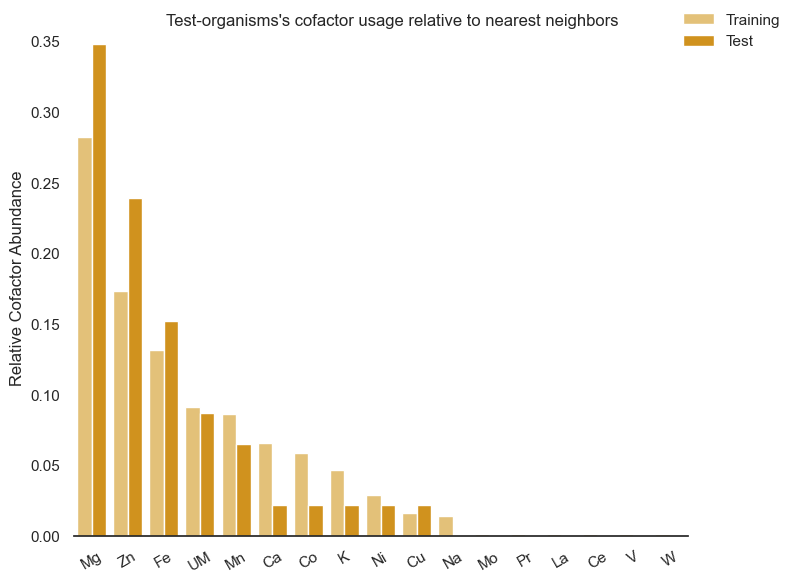

In [ ]:
import seaborn as sns
sns.set_theme(style="white")

colors = ["#f5c767", "#ee9b00"]

g = sns.catplot(
    data=counts, kind="bar",
    x="CofactorFinal", y="ra", hue="Set", 
    palette=colors, alpha=1, height=6, aspect=8/6
)

g.despine(left=True)
g.set_axis_labels("", "Relative Cofactor Abundance")
g.tick_params(axis='x', rotation=30)
g.fig.suptitle("Test-organisms's cofactor usage relative to nearest neighbors", y=0.98, fontsize=12)
g.legend.set_loc("upper right")
g.legend.set_title("")
g.fig.set_size_inches(8, 6)

facet_figs.append(g.fig)

### Generate report

In [ ]:
import sys
sys.path.append("..")

import modules.media_report as mr

# List of media IDs to include
media_ids = ["1012a"]

# Generate the PDF
mr.generate_media_report(media_ids, output_pdf="my_media_report.pdf")


Fetching media 1012a...
PDF report saved as my_media_report.pdf


In [ ]:
from modules.utils import _get_session

session = _get_session()
media_id = "830"  # example

url = f'https://mediadive.dsmz.de/rest/medium/{media_id}'
response = session.get(url)
print(response.status_code)
print(response.json())


200
{'status': 200, 'count': 1, 'data': {'medium': {'id': 830, 'name': 'R2A MEDIUM', 'complex_medium': 'yes', 'min_pH': 7.2, 'max_pH': 7.2, 'source': 'DSMZ', 'link': 'https://www.dsmz.de/microorganisms/medium/pdf/DSMZ_Medium830.pdf'}, 'solutions': [{'id': 6528, 'name': 'Main sol. 830', 'volume': 1000, 'recipe': [{'recipe_order': 1, 'compound': 'Yeast extract', 'compound_id': 16, 'attribute': 'BD 212750', 'amount': 0.5, 'unit': 'g', 'optional': 0}, {'recipe_order': 2, 'compound': 'Proteose peptone', 'compound_id': 208, 'attribute': 'Difco no. 3', 'amount': 0.5, 'unit': 'g', 'optional': 0}, {'recipe_order': 3, 'compound': 'Casamino acids', 'compound_id': 101, 'amount': 0.5, 'unit': 'g', 'optional': 0}, {'recipe_order': 4, 'compound': 'Glucose', 'compound_id': 5, 'amount': 0.5, 'unit': 'g', 'optional': 0}, {'recipe_order': 5, 'compound': 'Starch', 'compound_id': 199, 'attribute': 'soluble', 'amount': 0.5, 'unit': 'g', 'optional': 0}, {'recipe_order': 6, 'compound': 'Na-pyruvate', 'compoun

In [ ]:
with PdfPages("report.pdf") as pdf:
    # Save your existing figures first
    for fig_item in facet_figs:
        pdf.savefig(fig_item)
        plt.close(fig_item)
    
    # Save the table figure (pass the Figure object, not the Table)
    #pdf.savefig(fig)
    #plt.close(fig)